# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [1]:
print("Hello World! We are learning deep learning.")


Hello World! We are learning deep learning.


In [2]:

import pandas as pd

customerData = pd.read_csv(r"C:\Users\tcetiner\PycharmProjects\CustomerChurnForecasting\data\customer-churn.csv")
customerData.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:

from sklearn.model_selection import train_test_split

churn = customerData["Churn"].map({"Yes": 1, "No": 0})

features = customerData.drop(["Churn", "customerID"], axis=1)

features = pd.get_dummies(features,drop_first=True)
print(features.head())

X_train, X_test, y_train, y_test = train_test_split(features, churn, test_size=0.2)
print("Features printing")
features.head()
print(X_test.columns)



   SeniorCitizen  tenure  MonthlyCharges  gender_Male  Partner_Yes  \
0              0       1           29.85        False         True   
1              0      34           56.95         True        False   
2              0       2           53.85         True        False   
3              0      45           42.30         True        False   
4              0       2           70.70        False        False   

   Dependents_Yes  PhoneService_Yes  MultipleLines_No phone service  \
0           False             False                            True   
1           False              True                           False   
2           False              True                           False   
3           False             False                            True   
4           False              True                           False   

   MultipleLines_Yes  InternetService_Fiber optic  ...  TotalCharges_995.35  \
0              False                        False  ...                Fal

In [4]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_fitted = scaler.fit_transform(X_train)
X_test_fitted = scaler.transform(X_test)
print("Printing values")
print(X_train_fitted)


Printing values
[[-0.4377492  -1.26833755 -1.3364638  ... -0.01332386 -0.01332386
  -0.01332386]
 [ 2.28441306 -0.00778759  0.68816575 ... -0.01332386 -0.01332386
  -0.01332386]
 [-0.4377492   0.35817853 -1.30167066 ... -0.01332386 -0.01332386
  -0.01332386]
 ...
 [-0.4377492   1.53740268  0.50260232 ... -0.01332386 -0.01332386
  -0.01332386]
 [-0.4377492  -0.94303433 -0.63397368 ... -0.01332386 -0.01332386
  -0.01332386]
 [-0.4377492   0.76480755 -1.32320927 ... -0.01332386 -0.01332386
  -0.01332386]]


In [5]:

from tensorflow import keras
from tensorflow.keras import layers





model = keras.Sequential([
    keras.Input(shape=(X_train_fitted.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_fitted, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)


loss, accuracy = model.evaluate(X_test_fitted, y_test)
print("Test Accuracy:", accuracy)
model.save("model.keras")


Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7153 - loss: 0.5484 - val_accuracy: 0.7338 - val_loss: 0.5045
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9221 - loss: 0.2210 - val_accuracy: 0.7258 - val_loss: 0.5414
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9712 - loss: 0.0776 - val_accuracy: 0.7054 - val_loss: 0.6032
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9822 - loss: 0.0445 - val_accuracy: 0.7098 - val_loss: 0.6336
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9818 - loss: 0.0372 - val_accuracy: 0.7072 - val_loss: 0.6820
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9838 - loss: 0.0320 - val_accuracy: 0.6974 - val_loss: 0.7560
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9851 - loss: 0.0303 - val_accuracy: 0.7001 - val_loss: 0.7445
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9845 - loss: 0.0270 - val_accuracy: 0.

In [6]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\tcetiner\PycharmProjects\CustomerChurnForecasting\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


PermutationExplainer explainer:  10%|█         | 3/30 [00:00<?, ?it/s]

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


PermutationExplainer explainer:  17%|█▋        | 5/30 [00:12<00:14,  1.67it/s]

...

PermutationExplainer explainer:  97%|█████████▋| 29/30 [00:38<00:01,  1.11s/it]

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


PermutationExplainer explainer: 100%|██████████| 30/30 [00:39<00:00,  1.09s/it]

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


PermutationExplainer explainer: 31it [00:40,  1.45s/it]                        


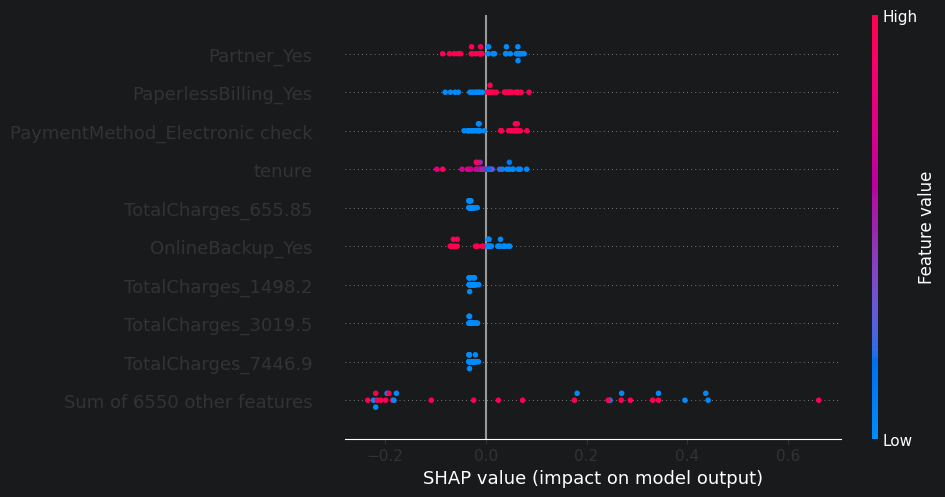

In [7]:


import shap




explainer = shap.Explainer(model.predict, X_train_fitted[:30], feature_names=X_train.columns)

shap_values = explainer(X_test_fitted[:30])

shap.plots.beeswarm(shap_values)
